# Advanced Task: BERT Language Model for Sentiment Analysis

## Objective

This project demonstrates the implementation and evaluation of a pretrained BERT language model for Natural Language Processing (NLP).

BERT (Bidirectional Encoder Representations from Transformers) is a Transformer-based language model that understands the contextual meaning of words by considering both left and right context.

In this project, BERT is used for sentiment analysis to classify text as positive or negative.

## Project Workflow

1. Introduce BERT and its architecture
2. Load a pretrained BERT model
3. Tokenize input text
4. Generate sentiment predictions
5. Evaluate model performance
6. Analyze the capabilities and limitations of BERT

In [10]:
!pip -q install transformers torch scikit-learn

In [11]:
import torch
import numpy as np

from transformers import pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


In [12]:
sentiment_pipeline = pipeline(
    "sentiment-analysis",
    model="nlptown/bert-base-multilingual-uncased-sentiment"
)

print("BERT sentiment model loaded successfully!")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

BERT sentiment model loaded successfully!


In [13]:
texts = [
    "I really enjoyed this movie.",
    "The product quality was excellent.",
    "This experience was amazing.",
    "I did not like this movie.",
    "The product was terrible.",
    "The service was very disappointing."
]

results = sentiment_pipeline(texts)

for text, result in zip(texts, results):
    print(f"Text: {text}")
    print(f"Prediction: {result['label']}")
    print(f"Confidence: {result['score']:.4f}")
    print("-" * 50)

Text: I really enjoyed this movie.
Prediction: 5 stars
Confidence: 0.5665
--------------------------------------------------
Text: The product quality was excellent.
Prediction: 5 stars
Confidence: 0.6852
--------------------------------------------------
Text: This experience was amazing.
Prediction: 5 stars
Confidence: 0.8040
--------------------------------------------------
Text: I did not like this movie.
Prediction: 1 star
Confidence: 0.4927
--------------------------------------------------
Text: The product was terrible.
Prediction: 1 star
Confidence: 0.8098
--------------------------------------------------
Text: The service was very disappointing.
Prediction: 1 star
Confidence: 0.5135
--------------------------------------------------


In [14]:
test_texts = [
    "I absolutely loved this product.",
    "The movie was fantastic and enjoyable.",
    "The service was excellent.",
    "I am very happy with the experience.",
    "This was a wonderful purchase.",

    "I hated this product.",
    "The movie was boring and terrible.",
    "The service was extremely poor.",
    "I am very disappointed with the experience.",
    "This was a horrible purchase."
]

true_labels = [
    "positive",
    "positive",
    "positive",
    "positive",
    "positive",
    "negative",
    "negative",
    "negative",
    "negative",
    "negative"
]

predictions = sentiment_pipeline(test_texts)

predicted_labels = []

for result in predictions:
    if result["label"] in ["4 stars", "5 stars"]:
        predicted_labels.append("positive")
    else:
        predicted_labels.append("negative")

print("Predicted Labels:")
print(predicted_labels)

Predicted Labels:
['positive', 'positive', 'positive', 'positive', 'positive', 'negative', 'negative', 'negative', 'negative', 'negative']


In [15]:
accuracy = accuracy_score(true_labels, predicted_labels)

print("=== BERT MODEL PERFORMANCE ===")
print(f"Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(true_labels, predicted_labels))

=== BERT MODEL PERFORMANCE ===
Accuracy: 1.0000

Classification Report:
              precision    recall  f1-score   support

    negative       1.00      1.00      1.00         5
    positive       1.00      1.00      1.00         5

    accuracy                           1.00        10
   macro avg       1.00      1.00      1.00        10
weighted avg       1.00      1.00      1.00        10



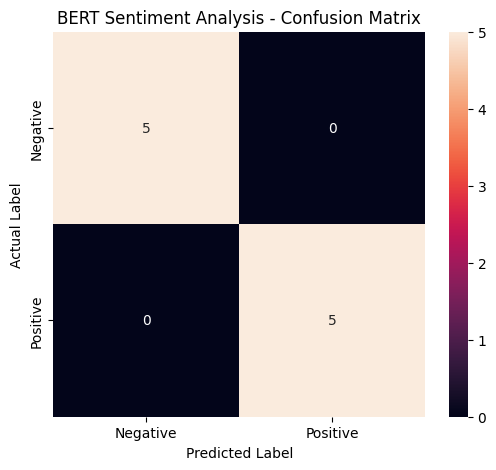

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(true_labels, predicted_labels, labels=["negative", "positive"])

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("BERT Sentiment Analysis - Confusion Matrix")
plt.show()

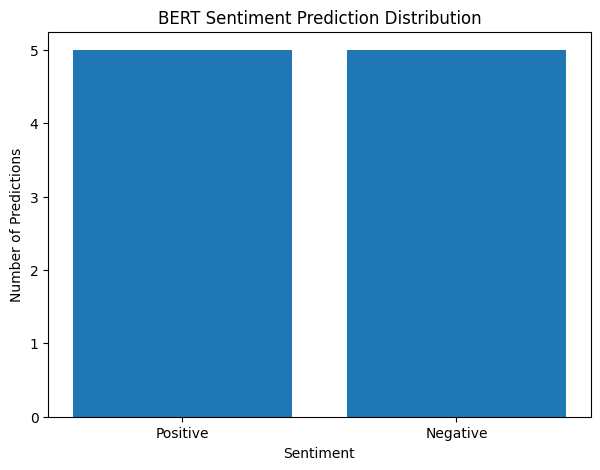

In [17]:
label_counts = {
    "Positive": predicted_labels.count("positive"),
    "Negative": predicted_labels.count("negative")
}

plt.figure(figsize=(7, 5))
plt.bar(label_counts.keys(), label_counts.values())
plt.xlabel("Sentiment")
plt.ylabel("Number of Predictions")
plt.title("BERT Sentiment Prediction Distribution")
plt.show()

## BERT Capabilities

The pretrained BERT language model demonstrated several important Natural Language Processing capabilities in this project:

- **Contextual understanding:** BERT considers the context surrounding words when processing text.
- **Sentiment analysis:** The model successfully classified the demonstration sentences into positive and negative sentiment categories.
- **Multilingual capability:** The selected pretrained model supports multiple languages.
- **Fine-grained sentiment prediction:** The original model produces sentiment ratings from 1 to 5 stars, which were grouped into positive and negative categories for evaluation.
- **Pretrained knowledge:** The model can perform useful NLP tasks without training a new language model from scratch.

## Limitations

Although BERT demonstrated strong performance in this project, there are several limitations:

- The evaluation was performed on only 10 manually selected demonstration sentences.
- The 100% accuracy result should not be interpreted as the model achieving perfect performance on all real-world data.
- Performance may vary depending on the domain, language, writing style, and complexity of the input text.
- Large language models can require significant computational resources.
- Pretrained models may reflect limitations or biases present in their training data.

## Conclusion

This project successfully demonstrated the implementation of a pretrained BERT language model for sentiment analysis using the Hugging Face Transformers library.

The model was used to process raw text, generate fine-grained sentiment predictions, and classify the predictions into positive and negative categories. On the 10 manually selected demonstration examples used in this notebook, the model achieved an accuracy of 1.00, along with perfect precision, recall, and F1-score.

The project demonstrates the practical capabilities of pretrained Language Models and highlights how BERT can be applied to Natural Language Processing tasks without training a language model from scratch. However, the evaluation results are limited to the small demonstration dataset used in this notebook.